In [27]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [28]:
import gensim.downloader as api

fasttext = api.load('glove-twitter-25')

In [29]:
fasttext.most_similar(positive = ['dog'])

[('cat', 0.9590821266174316),
 ('dogs', 0.9244232177734375),
 ('horse', 0.9209403395652771),
 ('monkey', 0.9146843552589417),
 ('pig', 0.9116264581680298),
 ('kid', 0.902455747127533),
 ('puppy', 0.9024084210395813),
 ('bear', 0.9013873934745789),
 ('pet', 0.8971228003501892),
 ('dirty', 0.8893660306930542)]

In [30]:
fasttext.most_similar(positive = ['king', 'woman'], negative = ['man'])

[('meets', 0.8841923475265503),
 ('prince', 0.832163393497467),
 ('queen', 0.8257461190223694),
 ('’s', 0.8174097537994385),
 ('crow', 0.813499391078949),
 ('hunter', 0.8131037950515747),
 ('father', 0.8115833401679993),
 ('soldier', 0.81113600730896),
 ('mercy', 0.8082392811775208),
 ('hero', 0.8082262277603149)]

In [31]:
import re
import string
from collections import Counter

class Vocabulary:
    def __init__(self, texts: list[str], min_freq: int = 10):
        text = ' '.join(texts)
        text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F]|[0-9a-fA-F]))+', ' ', text)
        text = re.sub('[^a-zA-Z]', ' ', text)

        while '  ' in text:
            text = text.replace('  ', ' ')

        words = text.strip().lower().split()

        c = Counter(words)

        self.vocabulary = list(set([word for word in words if c[word] >= min_freq]))
        self.vocabulary.append('<unk>')
        self._idx2word = {i: word for i, word in enumerate(self.vocabulary)}
        self._word2idx = {word: i for i, word in enumerate(self.vocabulary)}

    def get_vocabulary(self):
        return self.vocabulary

    def word2idx(self, word):
        if word in self._word2idx:
            return self._word2idx[word]
        return self._word2idx['<unk>']

    def idx2word(self, idx):
        if idx in self._idx2word:
            return self._idx2word[idx]
        return '<unk>'

    def encode(self, text):
        text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F]|[0-9a-fA-F]))+', ' ', text)
        text = re.sub('[^a-zA-Z]', ' ', text)

        while '  ' in text:
            text = text.replace('  ', ' ')

        text = text.strip().lower()

        result = []

        for word in text.split():
            result.append(self.word2idx(word))

        return result

    def build_vectors(self, fasttext):
        vectors = []

        for word in self.vocabulary:
            if fasttext.has_index_for(word):
                vectors.append(fasttext[word])
            else:
                vectors.append(np.zeros(25))
        return np.stack(vectors)

<>:8: SyntaxWarning: invalid escape sequence '\('
<>:37: SyntaxWarning: invalid escape sequence '\('
<>:8: SyntaxWarning: invalid escape sequence '\('
<>:37: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_55/1157614319.py:8: SyntaxWarning: invalid escape sequence '\('
  text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F]|[0-9a-fA-F]))+', ' ', text)
/tmp/ipykernel_55/1157614319.py:37: SyntaxWarning: invalid escape sequence '\('
  text = re.sub('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F]|[0-9a-fA-F]))+', ' ', text)


### Датасет с тональностью отзыва - позитивный и негативный

### Кастомный класс датасета

In [32]:
# Должен принимать на вход датафрейм, а не читать по пути
class IMDB:
    def __init__(self, df, vocab):
        self.df = df
        texts = self.df['review'].values
        
        self.vocab = vocab #Vocabulary(texts, min_freq = 5)
        self.label2idx = {'positive': 0, 'negative': 1}

    def __getitem__(self, idx):
        text = self.df['review'].loc[idx]
        label = self.label2idx[self.df['sentiment'].loc[idx]]
        
        text = torch.LongTensor(self.vocab.encode(text))

        label = torch.FloatTensor([label])

        return text, label

    def __len__(self):
        return len(self.df)

### Разделим выборку на тренировочную и тестовую

In [33]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/artembez/imdb-review/IMDB Dataset.csv')
df_train, df_test = np.split(df, [45000], axis=0)
df_train = df_train.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

vocab = Vocabulary(df_train['review'].values, min_freq = 5)
train_dataset, test_dataset = IMDB(df_train, vocab), IMDB(df_test, vocab)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### Настроим collate_fn для работы с батчами (все тексты разного размера)

In [34]:
# будем приводить векторы каждого предложения к одинаковой длине
from torch.nn.utils.rnn import pad_sequence

pad_idx = len(vocab.vocabulary)

def collate_fn(batch):
    texts = pad_sequence([b[0] for b in batch], padding_value = pad_idx, batch_first = True)
    labels = torch.stack([b[1] for b in batch])
    return texts, labels

In [35]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, collate_fn = collate_fn, num_workers = 4, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False, collate_fn = collate_fn, num_workers = 4, pin_memory = True)

In [36]:
b = next(iter(train_loader))

In [37]:
b[0]

tensor([[33984,   559, 37453,  ..., 37529, 37529, 37529],
        [31981, 23348,  2852,  ..., 37529, 37529, 37529],
        [ 9063, 35720, 20799,  ..., 37529, 37529, 37529],
        ...,
        [20340, 16821, 31577,  ..., 37529, 37529, 37529],
        [34264, 13112, 17111,  ..., 37529, 37529, 37529],
        [36232,  5462, 14364,  ..., 37529, 37529, 37529]])

### Создадим нейронную сеть для классификации текстов

In [38]:
import torch.nn.functional as F
from torch import nn

class TextCNN(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, pad_idx):
        super().__init__()

        # padding_idx - индекс паддинга, чтобы вектор для него не строился
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)

        self.convs = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels = 1,
                    out_channels = 16,
                    kernel_size = (num_embs, embedding_dim)
                )
                for num_embs in [2, 3, 4, 5]
            ]
        )
        self.fc = nn.Linear(4 * 16, 1)
        self.dropout = nn.Dropout(0.2)

    # проходим по предложению 4 свертками (2, 3, 4, 5 эмбеддингов слов подряд)
    # каждый использует по 16 фильтров, 16 паттернов - получает 16 списков из чисел
    # для каждого слоя делаем макспулинг по каждому из 16 списков - получаем список из 16 чисел в каждом слое
    # на вход полносвязного слоя по 16 чисел для каждого из 4 слоев (16 * 4)
    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)

        x = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        x = [F.max_pool1d(_, _.shape[2]).squeeze(2) for _ in x]
        x = self.dropout(torch.cat(x, dim = 1))

        return self.fc(x)

In [39]:
model = TextCNN(vocab_size = len(vocab.vocabulary) + 1, embedding_dim = 25, pad_idx = pad_idx)

In [40]:
vectors = vocab.build_vectors(fasttext)

In [41]:
vectors.shape

(37529, 25)

In [42]:
# матрица эмбеддингов - появился паддинг
model.embedding.weight.shape

torch.Size([37530, 25])

In [43]:
model.embedding.weight.data[:len(vectors)] = torch.from_numpy(vectors)

In [44]:
model.embedding.weight

Parameter containing:
tensor([[-0.4564, -0.5636,  1.2949,  ...,  0.8795, -0.0830, -1.0688],
        [-0.5000, -1.2040,  0.2137,  ..., -0.1799, -0.5347, -0.7650],
        [ 0.7385, -0.0508, -1.2915,  ..., -0.2167,  0.3115, -1.4101],
        ...,
        [-0.3857, -0.0863, -0.1493,  ..., -0.9316, -1.6045, -0.9401],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       requires_grad=True)

### Определим функции для обучения

In [45]:
from tqdm import tqdm

def binary_accuracy(
    preds, y
):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train(
    model,
    loader,
    optimizer,
    loss_fn,
    device
):
    model.train()
    train_loss = 0
    train_accuracy = 0

    for x, y in tqdm(loader, desc = 'train'):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)

        loss = loss_fn(output, y)
        train_loss += loss.item()
        train_accuracy += binary_accuracy(output, y).item()
        
        loss.backward()
        optimizer.step()

    train_loss /= len(loader)
    train_accuracy /= len(loader)

    return train_loss, train_accuracy
    

In [46]:
@torch.inference_mode()
def evaluate(
    model,
    loader,
    loss_fn,
    device
):
    model.eval()
    total_loss = 0
    total_accuracy = 0
    for x, y in tqdm(loader, desc = 'evaluate'):
        x, y = x.to(device), y.to(device)

        output = model(x)
        
        loss = loss_fn(output, y)
        total_loss += loss.item()
        total_accuracy += binary_accuracy(output, y).item()
        
    total_loss /= len(loader)
    total_accuracy /= len(loader)
    return total_loss, total_accuracy

In [47]:
def plot_stats(
    train_loss_history: list[float],
    eval_loss_history: list[float],
    train_accuracy_history: list[float],
    eval_accuracy_history: list[float],
    title: str
):
    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_loss_history, label = 'Train loss')
    plt.plot(eval_loss_history, label = 'Evaluation loss')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_accuracy_history, label = 'Train accuracy')
    plt.plot(eval_accuracy_history, label = 'Evaluation accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [48]:
from IPython.display import clear_output
def whole_train_value_cycle(
    model,
    train_loader,
    test_loader,
    optimizer,
    loss_fn,
    device,
    num_epochs,
    title
):
    train_loss_history = []
    eval_loss_history = []
    train_accuracy_history = []
    eval_accuracy_history = []
    
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        eval_loss, eval_accuracy = evaluate(model, test_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        eval_loss_history.append(eval_loss)
        train_accuracy_history.append(train_accuracy)
        eval_accuracy_history.append(eval_accuracy)

        clear_output()
        plot_stats(
            train_loss_history,
            eval_loss_history,
            train_accuracy_history,
            eval_accuracy_history,
            title
        )

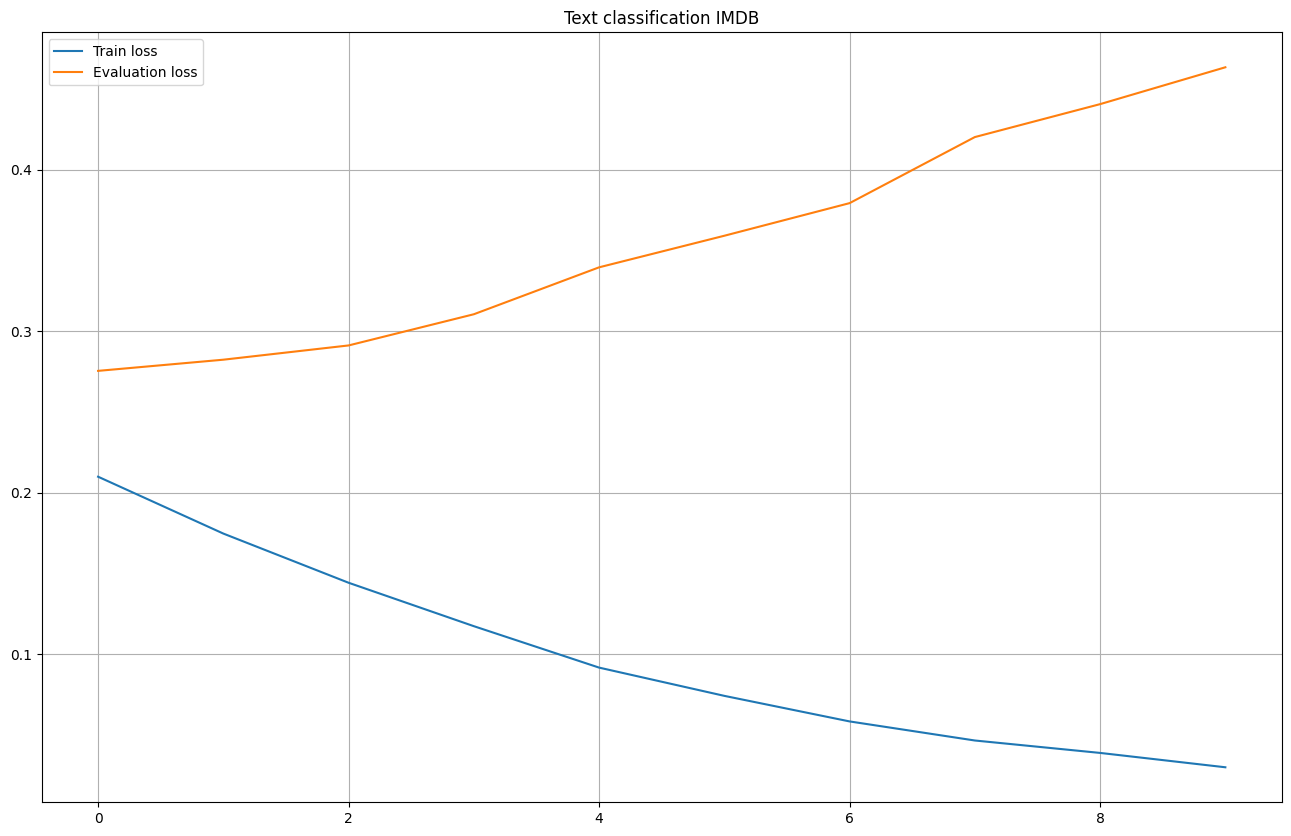

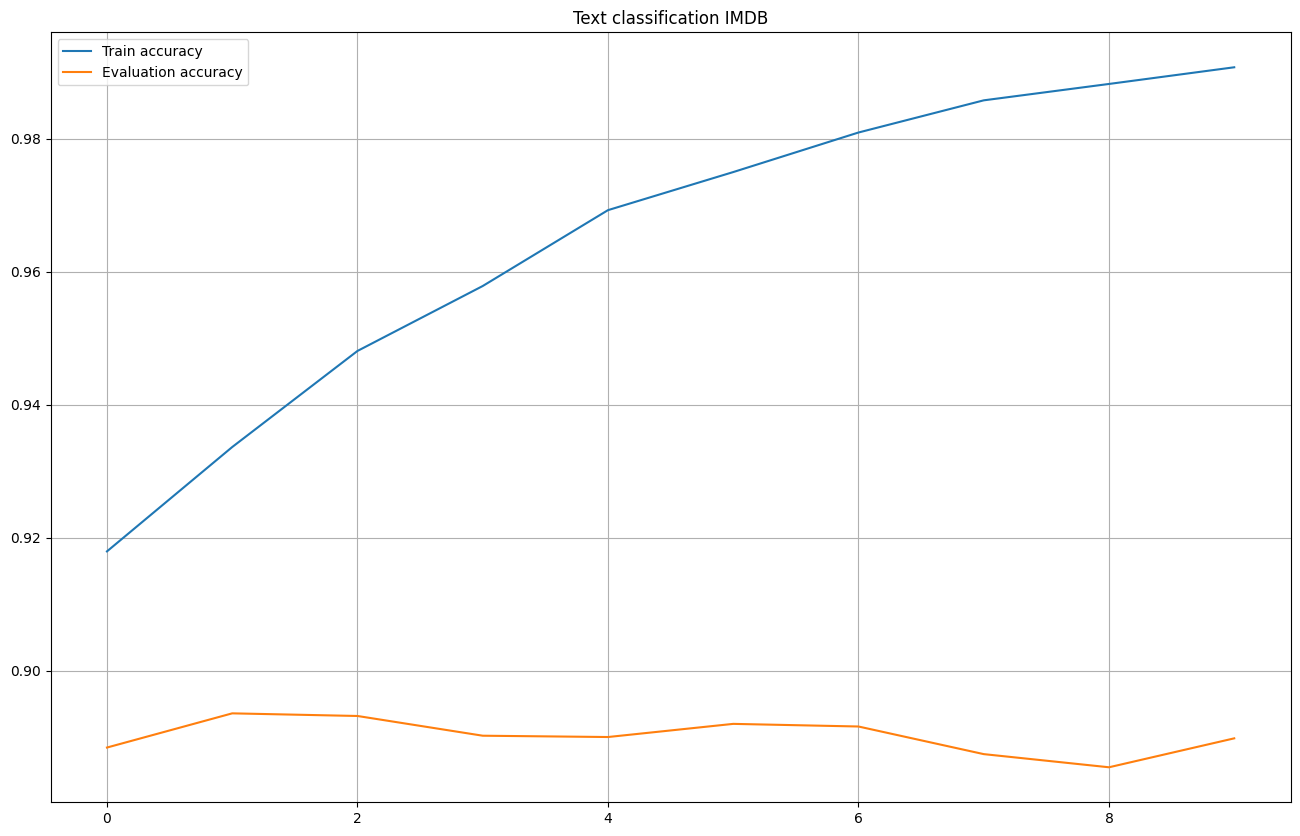

In [60]:
from torch.optim import Adam
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

loss_fn = nn.BCEWithLogitsLoss()
model = model.to(device)
optimizer = Adam(model.parameters(), lr = 1e-3)
whole_train_value_cycle(model, train_loader, test_loader, optimizer, loss_fn, device, 10, 'Text classification IMDB')

In [61]:
@torch.inference_mode()
def save_model(model, loader):
    model.eval()
    all_preds = []
    for x, _ in tqdm(loader, desc = 'Test'):
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()
        all_preds.append(preds.cpu())
    all_preds = torch.cat(all_preds).squeeze(1)
    torch.save(all_preds, 'my_predictions.pt')

In [62]:
save_model(model, test_loader)

Test: 100%|██████████| 79/79 [00:00<00:00, 86.20it/s] 
